In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Настройка визуализации
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)

# 🔵 1. Генерация данных для A/B теста

In [3]:
print("=== A/B ТЕСТИРОВАНИЕ: ПОЛНЫЙ ЦИКЛ ===")
#Генерируем данные
np.random.seed(42)  # воспроизводимость

# Параметры
sample_size = 5000
baseline_conversion = 0.10    # 10% конверсия в группе A
effect_size = 0.02            # ожидаемый рост +2% в группе B

# Группа A: контрольная (старая версия)
group_a_data = np.random.choice([0, 1], size=sample_size,
                                p=[1-baseline_conversion, baseline_conversion])

# Группа B: тестовая (новая версия с улучшением)
group_b_data = np.random.choice([0, 1], size=sample_size,
                                p=[1-(baseline_conversion+effect_size),
                                   baseline_conversion+effect_size])

=== A/B ТЕСТИРОВАНИЕ: ПОЛНЫЙ ЦИКЛ ===


In [4]:
# Создаём DataFrame
ab_test_data = pd.DataFrame({
    'user_id': range(sample_size * 2),
    'group': ['A'] * sample_size + ['B'] * sample_size,
    'converted': np.concatenate([group_a_data, group_b_data])
})

✅ Результат:

-	Две группы по 5000 пользователей
-	Конверсия A: ~10%, B: ~12%
-	Данные готовы к анализу

# 🔵 2. Расчёт метрик по группам

In [5]:
group_stats = ab_test_data.groupby('group')['converted'].agg([
    ('total_users', 'count'),
    ('conversions', 'sum'),
    ('conversion_rate', 'mean')
]).round(4)

group_stats['conversion_rate_pct'] = (group_stats['conversion_rate'] * 100).round(2)

# 🔵 3. Визуализация результатов

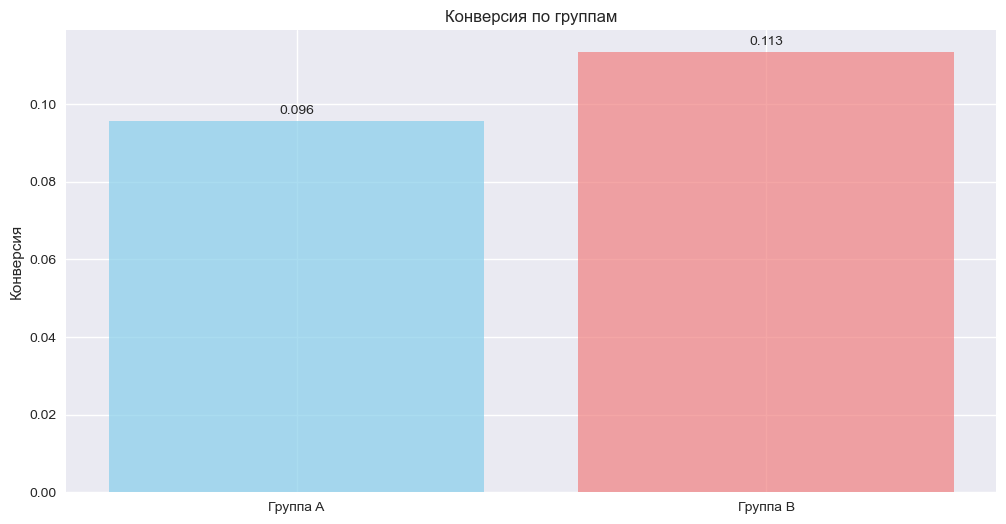

In [8]:
# 📈 График 1: Конверсия по группам
plt.bar(['Группа A', 'Группа B'], 
        [group_stats.loc['A', 'conversion_rate'], 
         group_stats.loc['B', 'conversion_rate']],
        color=['skyblue', 'lightcoral'], alpha=0.7)
plt.title('Конверсия по группам')
plt.ylabel('Конверсия')
for i, v in enumerate([group_stats.loc['A', 'conversion_rate'], 
                       group_stats.loc['B', 'conversion_rate']]):
    plt.text(i, v + 0.001, f'{v:.3f}', ha='center', va='bottom')
plt.show()

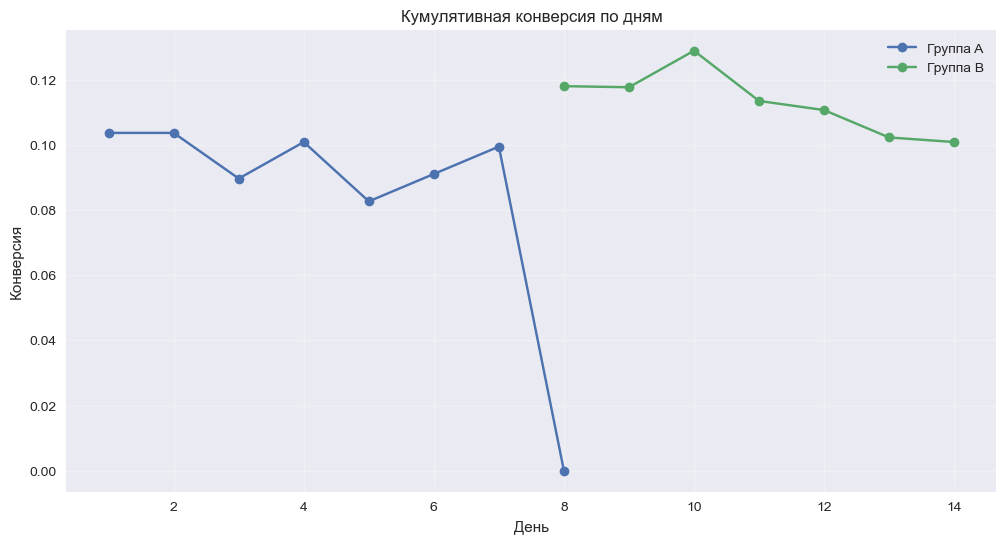

In [9]:
#График 2: Кумулятивная конверсия (по дням)

days = 14
daily_data = []

for day in range(days):
    day_sample = int(sample_size * 2 / days)
    daily_subset = ab_test_data.iloc[day * day_sample:(day + 1) * day_sample]
    daily_stats = daily_subset.groupby('group')['converted'].mean().reset_index()
    daily_stats['day'] = day + 1
    daily_data.append(daily_stats)

daily_df = pd.concat(daily_data)

for group in ['A', 'B']:
    group_data = daily_df[daily_df['group'] == group]
    plt.plot(group_data['day'], group_data['converted'], label=f'Группа {group}', marker='o')

plt.title('Кумулятивная конверсия по дням')
plt.xlabel('День')
plt.ylabel('Конверсия')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


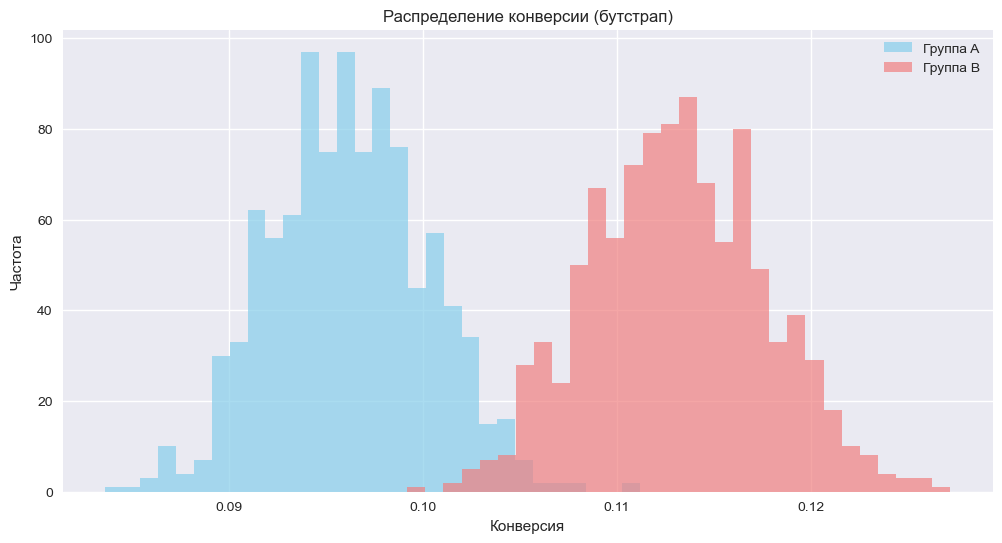

In [11]:
# 📈 График 3: Бутстрап-распределение конверсии
def bootstrap_ci(data, n_bootstrap=1000):
    boot_means = []
    for _ in range(n_bootstrap):
        boot_sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(boot_sample))
    return np.percentile(boot_means, [2.5, 97.5])

boot_a = [np.mean(np.random.choice(group_a_data, size=len(group_a_data), replace=True)) for _ in range(1000)]
boot_b = [np.mean(np.random.choice(group_b_data, size=len(group_b_data), replace=True)) for _ in range(1000)]

plt.hist(boot_a, bins=30, alpha=0.7, label='Группа A', color='skyblue')
plt.hist(boot_b, bins=30, alpha=0.7, label='Группа B', color='lightcoral')
plt.title('Распределение конверсии (бутстрап)')
plt.xlabel('Конверсия')
plt.ylabel('Частота')
plt.legend()
plt.show()


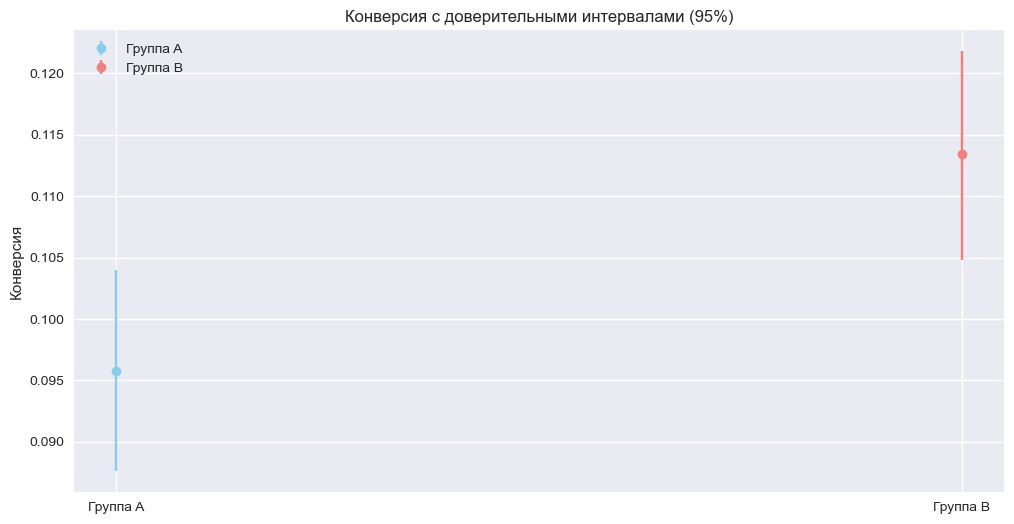

In [12]:
# 📈 График 4: Доверительные интервалы (95%)
ci_a = bootstrap_ci(group_a_data)
ci_b = bootstrap_ci(group_b_data)

plt.errorbar(['Группа A'], [group_stats.loc['A', 'conversion_rate']], 
             yerr=[[group_stats.loc['A', 'conversion_rate'] - ci_a[0]], 
                   [ci_a[1] - group_stats.loc['A', 'conversion_rate']]], 
             fmt='o', capsize=5, label='Группа A', color='skyblue')

plt.errorbar(['Группа B'], [group_stats.loc['B', 'conversion_rate']], 
             yerr=[[group_stats.loc['B', 'conversion_rate'] - ci_b[0]], 
                   [ci_b[1] - group_stats.loc['B', 'conversion_rate']]], 
             fmt='o', capsize=5, label='Группа B', color='lightcoral')

plt.title('Конверсия с доверительными интервалами (95%)')
plt.ylabel('Конверсия')
plt.legend()
plt.show()

# 🔵 4. Статистический анализ

In [13]:
# ✅ T-тест (сравнение средних)

t_stat, t_p_value = stats.ttest_ind(group_a_data, group_b_data)

In [16]:
print(t_stat, t_p_value)

-2.876368137832723 0.0040313082018820145


In [14]:
# ✅ Z-тест (для пропорций)

def z_test_proportions(conv_a, users_a, conv_b, users_b):
    p1 = conv_a / users_a
    p2 = conv_b / users_b
    p_pool = (conv_a + conv_b) / (users_a + users_b)
    
    z = (p1 - p2) / np.sqrt(p_pool * (1 - p_pool) * (1/users_a + 1/users_b))
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    
    return z, p_value

z_stat, z_p_value = z_test_proportions(
    group_stats.loc['A', 'conversions'],
    group_stats.loc['A', 'total_users'],
    group_stats.loc['B', 'conversions'],
    group_stats.loc['B', 'total_users']
)

In [15]:
#✅ Хи-квадрат тест (независимость категорий)

contingency_table = pd.crosstab(ab_test_data['group'], ab_test_data['converted'])
chi2, chi_p_value, _, _ = stats.chi2_contingency(contingency_table)

In [17]:
print(chi2, chi_p_value, _, _)

8.081458194442725 0.004472044654175628 [[4477.  523.]
 [4477.  523.]] [[4477.  523.]
 [4477.  523.]]


# 🔵 5. Мощность теста и размер эффекта

In [18]:
conversion_diff = group_stats.loc['B', 'conversion_rate'] - group_stats.loc['A', 'conversion_rate']
relative_improvement = (conversion_diff / group_stats.loc['A', 'conversion_rate']) * 100

print(f"Абсолютное улучшение: {conversion_diff:.4f} (+{conversion_diff*100:.2f}%)")
print(f"Относительное улучшение: {relative_improvement:.2f}%")


Абсолютное улучшение: 0.0176 (+1.76%)
Относительное улучшение: 18.37%


# 🔎 Расчет необходимого размера выборки

In [20]:
def calculate_sample_size(alpha=0.05, power=0.8, p1=0.1, p2=0.12):
    from statsmodels.stats.power import NormalIndPower
    from statsmodels.stats.proportion import proportion_effectsize
    
    effect_size = proportion_effectsize(p1, p2)
    analysis = NormalIndPower()
    sample_size = analysis.solve_power(effect_size, power=power, alpha=alpha, ratio=1.0)
    return int(np.ceil(sample_size))

In [21]:
required_sample = calculate_sample_size(p1=0.10, p2=0.12)
print(f"Минимальный размер каждой группы: {required_sample} пользователей")

Минимальный размер каждой группы: 3835 пользователей


# 🔵 6. Симуляция множественных тестов

In [28]:
def run_ab_test_simulation(baseline=0.1, effect=0.0, sample_size=1000, n_simulations=100):
    significant_results = 0
    for _ in range(n_simulations):
        group_a = np.random.choice([0, 1], size=sample_size, p=[1-baseline, baseline])
        group_b = np.random.choice([0, 1], size=sample_size, p=[1-(baseline+effect), baseline+effect])
        _, p_value = stats.ttest_ind(group_a, group_b)
        if p_value < 0.05:
            significant_results += 1
    return significant_results / n_simulations

In [29]:
# False Positive Rate (когда эффекта нет)
false_positive_rate = run_ab_test_simulation(effect=0.0, n_simulations=200)
print(f"False Positive Rate (когда эффекта нет): {false_positive_rate*100:.1f}%")  # ≈5%

False Positive Rate (когда эффекта нет): 4.0%


In [30]:
# True Positive Rate (когда эффект есть)
true_positive_rate = run_ab_test_simulation(effect=0.02, n_simulations=200)
print(f"True Positive Rate (когда эффект есть): {true_positive_rate*100:.1f}%")  # Чем выше — тем мощнее тест

True Positive Rate (когда эффект есть): 27.5%


In [31]:
# Идеальный тест: FP ≈ 5%, TP > 80% 
#________________________________________

# 🔵 7. Практические выводы

In [33]:
alpha = 0.05
is_significant = min(t_p_value, z_p_value, chi_p_value) < alpha

print("📊 РЕЗУЛЬТАТЫ A/B ТЕСТА:")
print(f"✅ Статистическая значимость: {'ДА' if is_significant else 'НЕТ'}")
print(f"📈 Конверсия группы A: {group_stats.loc['A', 'conversion_rate_pct']}%")
print(f"📈 Конверсия группы B: {group_stats.loc['B', 'conversion_rate_pct']}%")
print(f"🎯 Относительное улучшение: {relative_improvement:+.2f}%")

if is_significant:
    if conversion_diff > 0:
        print("🚀 ВЫВОД: Внедряем изменение! Группа B показала значимое улучшение.")
    else:
        print("📉 ВЫВОД: Оставляем старую версию. Группа A лучше.")
else:
    print("⚖️ ВЫВОД: Различия не значимы. Нужно больше данных.")

📊 РЕЗУЛЬТАТЫ A/B ТЕСТА:
✅ Статистическая значимость: ДА
📈 Конверсия группы A: 9.58%
📈 Конверсия группы B: 11.34%
🎯 Относительное улучшение: +18.37%
🚀 ВЫВОД: Внедряем изменение! Группа B показала значимое улучшение.


#🔵 8. Проверка сбалансированности групп

In [35]:
ab_test_data['age'] = np.random.normal(35, 10, len(ab_test_data)).astype(int).clip(18)
ab_test_data['device'] = np.random.choice(['mobile', 'desktop'], len(ab_test_data), p=[0.6, 0.4])

print("Распределение по устройствам:")
print(pd.crosstab(ab_test_data['group'], ab_test_data['device'], normalize='index').round(3))

print("\nСредний возраст по группам:")
print(ab_test_data.groupby('group')['age'].mean().round(1))


Распределение по устройствам:
device  desktop  mobile
group                  
A         0.409   0.591
B         0.404   0.596

Средний возраст по группам:
group
A    34.6
B    34.6
Name: age, dtype: float64


# 📊 Визуализация баланса

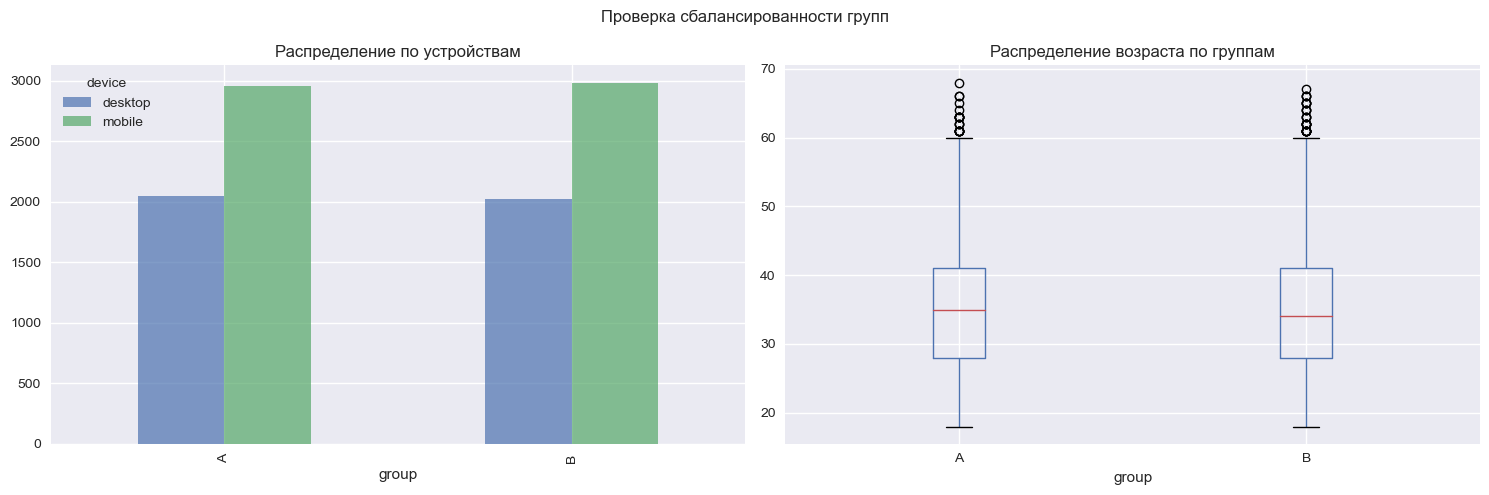

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Устройства
device_counts = ab_test_data.groupby(['group', 'device']).size().unstack()
device_counts.plot(kind='bar', ax=axes[0], alpha=0.7)
axes[0].set_title('Распределение по устройствам')

# Возраст
ab_test_data.boxplot(column='age', by='group', ax=axes[1])
axes[1].set_title('Распределение возраста по группам')

plt.suptitle('Проверка сбалансированности групп')
plt.tight_layout()
plt.show()

### 🔴 Если группы несбалансированы (например, в B больше мобильных пользователей), то разница может быть не из-за изменения, а из-за состава. 

🏁 Ключевые выводы
- ✅ 1. Проверяйте статистическую значимость:
p-value < 0.05 — минимальный порог 
- ✅ 2. Считайте размер эффекта: 
Даже если значимо, важно: +0.1% или +20%? 
- ✅ 3. Планируйте размер выборки заранее: 
Не останавливайте тест досрочно! 
- ✅ 4. Проверяйте баланс групп: 
Убедитесь, что различия не вызваны системной ошибкой разбиения 
- ✅ 5. Учитывайте бизнес-контекст: 
Даже значимый результат может быть экономически невыгодным 


🛠 Как применить в своей работе?
	
- A/B тест UI	____________Замените `converted` на `click_rate`,`time_on_page`
- Тест маркетингового письма____________	Метрика:`open_rate`, `purchase_made`
- Сравнение двух цен _____________	Метрика:`revenue_per_user`, `conversion_to_purchase`
- Анализ в Tableau _________	Экспортируй `теab_test_data.csv` → подключите к Tableau
- Автоматизация отчёта ___________	Оберните код в функцию +.to_csv()
